# Plot multi-gene subcellular expression

Load one subcellular CSV file and draw an overlaid scatter plot for multiple genes.

Expected CSV columns: `gene`, `x`, `y`.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
csv_path = Path(r"F:\st\SVGRN_subcellular\in_sim\g110_c05_n01\subcellular_data_hub\cell1_subcellular.csv")

# Add or remove gene ids here. Values can be strings or numbers.
#genes = ["2", "6", "10", "19", "80", "91"]
genes = ["19", "80", "40"]
point_size = 18
point_alpha = 0.65

In [16]:
if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

sub_df = pd.read_csv(csv_path)
required_cols = {"gene", "x", "y"}
missing_cols = required_cols.difference(sub_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

sub_df = sub_df.copy()
sub_df["gene"] = sub_df["gene"].astype(str)
selected_genes = [str(gene) for gene in genes]

gene_dfs = {gene: sub_df[sub_df["gene"] == gene] for gene in selected_genes}
summary_df = pd.DataFrame(
    {
        "gene": selected_genes,
        "expression_count": [len(gene_dfs[gene]) for gene in selected_genes],
    }
)

missing_genes = summary_df.loc[summary_df["expression_count"] == 0, "gene"].tolist()
present_genes = summary_df.loc[summary_df["expression_count"] > 0, "gene"].tolist()

print(f"Loaded: {csv_path}")
display(summary_df)

if missing_genes:
    available_genes = sorted(sub_df["gene"].unique())
    print(f"Missing genes: {missing_genes}")
    print(f"First 20 available genes: {available_genes[:20]}")

if not present_genes:
    raise ValueError("None of the selected genes were found in the CSV.")

Loaded: F:\st\SVGRN_subcellular\in_sim\g110_c05_n01\subcellular_data_hub\cell1_subcellular.csv


,gene,expression_count
0,19,18
1,80,81
2,40,95


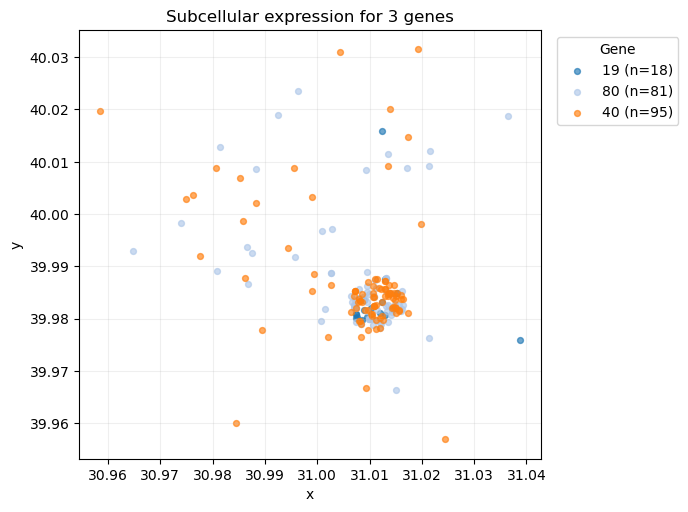

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))
cmap = plt.get_cmap("tab20")

for idx, gene in enumerate(present_genes):
    gene_df = gene_dfs[gene]
    ax.scatter(
        gene_df["x"],
        gene_df["y"],
        s=point_size,
        alpha=point_alpha,
        color=cmap(idx % cmap.N),
        label=f"{gene} (n={len(gene_df)})",
    )

ax.set_title(f"Subcellular expression for {len(present_genes)} genes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(title="Gene", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()